# Temperature-Broadened Rabi Flop vs Pulse Duration

This notebook simulates a single pulse with variable duration and plots the ensemble-averaged Rabi flop over many `pi` pulse areas.

Velocities are sampled from a 1D Maxwell-Boltzmann distribution, matching the temperature treatment in `mach_zehnder_with_temperature.ipynb`.

In [57]:
import sys

p = "2026-03-02 LMT sim"
if not any(p in s for s in sys.path):
    sys.path.append(p)

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from tqdm import tqdm
# from tqdm.notebook import tqdm

import version_info as vs
from lmt_simulation import (
    make_atom_states,
    transform_state_vector,
    pulse_interaction_in_borde_representation,
    calculate_ground_and_excited_probabilities,
    K_WAVEVECTOR,
    TRANSITION_FREQUENCY,
)

%matplotlib inline

In [59]:
np.random.seed(42)

T_SPECTROSCOPY = 45e-6
T_SLICE = T_SPECTROSCOPY * 5

RABI_FREQ_SPECTROSCOPY = 1.0 / (2.0 * T_SPECTROSCOPY)

MASS_ATOM = constants.atomic_mass * 87.0
TRANSITION_WAVELENGTH = 698e-9

TEMPERATURE = 200e-9
N_ATOMS = 30

N_DURATION_POINTS = 300
MAX_AREA_PI = 6.0

# Single-photon recoil frequency
F_RECOIL = constants.h / (MASS_ATOM * TRANSITION_WAVELENGTH**2)
BASE_DETUNING_HZ = F_RECOIL / 2  # Same detuning as MZ


In [60]:
sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.normal(0.0, sigma_v, size=N_ATOMS)
pulse_durations = np.linspace(0.0, MAX_AREA_PI * T_SPECTROSCOPY, N_DURATION_POINTS)
pulse_area_over_pi = pulse_durations / T_SPECTROSCOPY

print(f"sigma_v = {sigma_v:.3e} m/s")
print(f"Max pulse duration = {pulse_durations[-1] * 1e6:.1f} us ({MAX_AREA_PI:.1f} pi area)")

sigma_v = 4.372e-03 m/s
Max pulse duration = 270.0 us (6.0 pi area)


In [61]:
def calc_sliced_pulse_excitation_borde(
    spectroscopy_pulse_duration,
    slice_pulse_duration,
    detuning_hz=0.0,
    initial_velocity_z=0.0,
):
    # For the purposes of this simualtion, we'll assume that the two pulses have
    # their power tuned for maximum excitation

    rabi_freq_slice = 1.0 / (2.0 * slice_pulse_duration)
    

    m_values, positions, velocities, internal_amplitude, internal_is_ground = make_atom_states(
        initial_velocity_z=initial_velocity_z,
        c0=1,
        c1=0,
    )

    omega_laser = 2.0 * np.pi * (TRANSITION_FREQUENCY + detuning_hz)

    squiggly_amplitudes = transform_state_vector(
        m_values,
        internal_amplitude,
        internal_is_ground,
        omega_laser=omega_laser,
        t=0.0,
        z=0.0,
        vz=initial_velocity_z,
        inverse=False,
    )

    # Do a velocity slice
    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = pulse_interaction_in_borde_representation(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        positions,
        velocities,
        pulse_detuning=detuning_hz,
        t_pulse=slice_pulse_duration,
        pulse_rabi_freq=rabi_freq_slice,
        pulse_phase=0.0,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )

    # Clear out the ground state
    internal_amplitude_slice = transform_state_vector(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        omega_laser=omega_laser,
        t=slice_pulse_duration,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob_slice, excited_prob_slice = calculate_ground_and_excited_probabilities(
        m_values,
        internal_amplitude_slice,
        internal_is_ground,
    )
    atom_cleared_out = np.random.rand() < ground_prob_slice
    if atom_cleared_out:
        return float("nan")

    # Do a spectroscopy pulse
    m_values, squiggly_amplitudes, internal_is_ground, positions, velocities = pulse_interaction_in_borde_representation(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        positions,
        velocities,
        pulse_detuning=detuning_hz,
        t_pulse=spectroscopy_pulse_duration,
        pulse_rabi_freq=RABI_FREQ_SPECTROSCOPY,
        pulse_phase=0.0,
        k_sign=+1,
        k_wavevector=K_WAVEVECTOR,
        vz=initial_velocity_z,
    )

    internal_amplitude_final = transform_state_vector(
        m_values,
        squiggly_amplitudes,
        internal_is_ground,
        omega_laser=omega_laser,
        t=slice_pulse_duration + spectroscopy_pulse_duration,
        z=0.0,
        vz=initial_velocity_z,
        inverse=True,
    )

    ground_prob, excited_prob = calculate_ground_and_excited_probabilities(
        m_values,
        internal_amplitude_final,
        internal_is_ground,
    )

    total_prob = ground_prob + excited_prob
    return excited_prob / total_prob

In [62]:
excitation_traces = np.empty((N_ATOMS, N_DURATION_POINTS))

for ind_atom, velocity in enumerate(tqdm(velocities, desc="Simulating atoms")):
    for ind_duration, spectroscopy_pulse_duration in enumerate(pulse_durations):
        excitation_traces[ind_atom, ind_duration] = calc_sliced_pulse_excitation_borde(
            spectroscopy_pulse_duration=spectroscopy_pulse_duration,
            slice_pulse_duration=T_SLICE,
            detuning_hz=BASE_DETUNING_HZ,
            initial_velocity_z=velocity,
        )

Simulating atoms: 100%|██████████| 30/30 [00:05<00:00,  5.77it/s]


In [63]:
mean_excitation = np.nanmean(excitation_traces, axis=0)
std_excitation = np.nanstd(excitation_traces, axis=0)

ideal_excitation = np.array([
    calc_sliced_pulse_excitation_borde(
        spectroscopy_pulse_duration=pulse_duration,
        slice_pulse_duration=T_SLICE,
        detuning_hz=BASE_DETUNING_HZ,
        initial_velocity_z=0.0,
    )
    for pulse_duration in pulse_durations
])

In [64]:
num_surviving_atoms = np.sum(np.isfinite(excitation_traces[:,0]))

print(f"Survival probablility: {100*num_surviving_atoms / N_ATOMS:.1f}% ({num_surviving_atoms} / {N_ATOMS})")

Survival probablility: 20.0% (6 / 30)


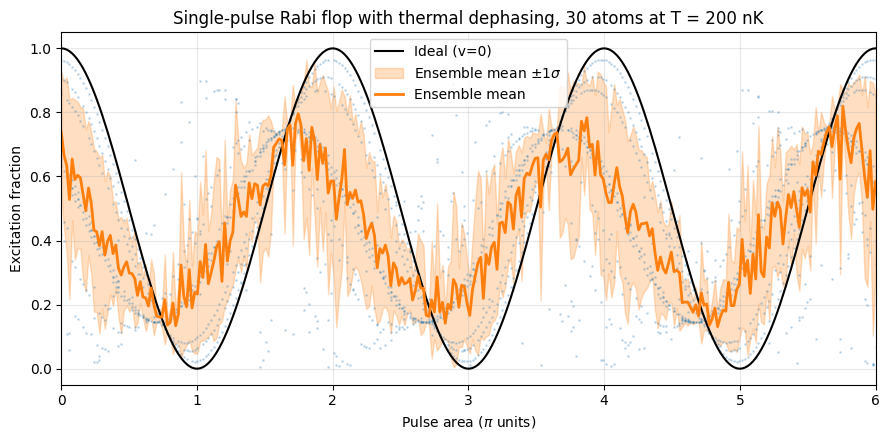

In [65]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for trace in excitation_traces:
    # print(trace)
    ax.plot(pulse_area_over_pi, trace, color="tab:blue", alpha=0.2, linestyle="", marker=".", markersize=2)

ax.plot(pulse_area_over_pi, ideal_excitation, color="black", lw=1.5, label="Ideal (v=0)")
ax.fill_between(
    pulse_area_over_pi,
    mean_excitation - std_excitation,
    mean_excitation + std_excitation,
    color="tab:orange",
    alpha=0.25,
    label=r"Ensemble mean $\pm 1\sigma$",
)
ax.plot(pulse_area_over_pi, mean_excitation, color="tab:orange", lw=2.0, label="Ensemble mean")

ax.set_xlabel(r"Pulse area ($\pi$ units)")
ax.set_ylabel("Excitation fraction")
ax.set_xlim(0, MAX_AREA_PI)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(
    rf"Single-pulse Rabi flop with thermal dephasing, {N_ATOMS} atoms at T = {TEMPERATURE * 1e9:.0f} nK"
)
fig.tight_layout()
vs.tag_plot(small=True)
